# MambaSegNet — Seismic Facies Segmentation

**Expected dataset layout**
```
dataset/
  train/
    data/     il_0.tif  xl_0.tif  il_1.tif  xl_1.tif  ...
    labels/   il_0.png   xl_0.png   il_1.png   xl_1.png   ...
  val/
    data/     xl_0.tif  xl_1.tif  ...
    labels/   xl_0.png   xl_1.png   ...
  test/
    data/     xl_0.tif  xl_1.tif  ...
    labels/   xl_0.png   xl_1.png   ...
```

Labels are integer PNG masks (one pixel value per class, 0-indexed).

## 0 — Configuration
Edit the paths and hyper-parameters here; everything else runs automatically.

In [1]:
import numpy as np
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("dataset")
TRAIN_DATA   = DATASET_ROOT / "data"        / "train"
TRAIN_LABELS = DATASET_ROOT / "annotations" / "train"
VAL_DATA     = DATASET_ROOT / "data"        / "val"
VAL_LABELS   = DATASET_ROOT / "annotations" / "val"
TEST_DATA    = DATASET_ROOT / "data"        / "test"
TEST_LABELS  = DATASET_ROOT / "annotations" / "test"

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

# ── Slice geometry ─────────────────────────────────────────────────────────
# Inlines and crosslines have different spatial sizes.  All slices are padded
# to a single canonical canvas so the DataLoader can form batches.
#
# Largest slice in the dataset: 1006 (H) × 590 (W)
# The model requires H and W to be divisible by 32, so we round up:
#   ceil(1006 / 32) * 32 = 1024
#   ceil( 590 / 32) * 32 =  608
#
# Change these only if your data has different native dimensions.
MAX_H, MAX_W   = 1006, 590   # native size of the largest slice type
CANVAS_H = int(np.ceil(MAX_H / 32) * 32)   # 1024  — model input height
CANVAS_W = int(np.ceil(MAX_W / 32) * 32)   #  608  — model input width

# ── Model ──────────────────────────────────────────────────────────────────
MODEL_VARIANT  = "tiny"    # tiny | small | base | large
NUM_CLASSES    = 6          # number of seismic facies (including background)
IN_CHANNELS    = 1          # 1 for single-channel amplitude, 3 for RGB-encoded
PRETRAINED     = True       # load VMamba ImageNet encoder weights

# ── Training ───────────────────────────────────────────────────────────────
EPOCHS         = 50
BATCH_SIZE     = 2
NUM_WORKERS    = 4
BASE_LR        = 1e-4
ENCODER_LR_SCALE = 0.1     # encoder lr = BASE_LR * ENCODER_LR_SCALE
WEIGHT_DECAY   = 1e-2
FREEZE_EPOCHS  = 5         # epochs to train decoder-only before unfreezing encoder
SEED           = 42

# ── Class names (edit to match your dataset) ───────────────────────────────
CLASS_NAMES = [f"facies_{i}" for i in range(NUM_CLASSES)]
# e.g. CLASS_NAMES = ["background", "channel", "mass_transport", "slope", "delta", "carbonate"]

## 1 — Imports & Setup

In [2]:
import sys, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tifffile
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore", category=UserWarning)

# Make sure the model files are on the path
sys.path.insert(0, str(Path(".").resolve()))
from mamba_seg_net    import mamba_seg_tiny, mamba_seg_small, mamba_seg_base, mamba_seg_large, DiceCELoss
from pretrained_utils import load_vmamba_pretrained, freeze_encoder, unfreeze_encoder, get_param_groups_layerwise_lr

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 4090
VRAM   : 25.4 GB


## 2 — Dataset

In [3]:
class SeismicFaciesDataset(Dataset):
    """
    Loads paired (seismic amplitude .tif, facies label .png) slices.

    Data   : .tif  — single-channel amplitude or arbitrary float32 array
    Labels : .png   — integer mask, one value per class (0-indexed)

    Mixed-size handling
    -------------------
    Inlines and crosslines have different spatial dimensions (e.g. 1006×590
    vs. a smaller crossline size).  PyTorch DataLoader requires every sample
    in a batch to share the same shape, so every slice is padded with
    reflection (amplitude) / edge (labels) to a single canonical canvas of
    (canvas_h, canvas_w) — typically the next multiples of 32 above the
    largest slice dimensions.  No information is lost: the padded region is
    never backpropagated through (labels there are set to ignore_index=-1).

    Preprocessing
    -------------
    - Per-slice z-score normalisation (robust across inline/crossline ranges).
    - Optional seismic-aware augmentations (flip, noise, amplitude scaling).
    - For IN_CHANNELS=3 the amplitude is broadcast to 3 channels.
    """

    # Seismic-specific augmentations applied only during training
    _AUGMENT_FLIP_H  = 0.5   # horizontal flip probability
    _AUGMENT_FLIP_V  = 0.3   # vertical flip probability
    _AUGMENT_NOISE   = 0.3   # additive Gaussian noise probability
    _AUGMENT_SCALE   = 0.3   # amplitude scaling probability

    IGNORE_INDEX = -1         # label value assigned to padded pixels

    def __init__(
        self,
        data_dir: Path,
        label_dir: Path,
        canvas_h: int,        # target H after padding (must be div by 32)
        canvas_w: int,        # target W after padding (must be div by 32)
        in_channels: int = 1,
        augment: bool = False,
        num_classes: int = 6,
    ):
        assert canvas_h % 32 == 0, f"canvas_h={canvas_h} must be divisible by 32"
        assert canvas_w % 32 == 0, f"canvas_w={canvas_w} must be divisible by 32"

        self.data_dir    = Path(data_dir)
        self.label_dir   = Path(label_dir)
        self.canvas_h    = canvas_h
        self.canvas_w    = canvas_w
        self.in_channels = in_channels
        self.augment     = augment
        self.num_classes = num_classes

        # Collect all .tif files that have a matching label
        self.samples = []
        il_count, xl_count = 0, 0
        for tiff_path in sorted(self.data_dir.glob("*.tif")):
            lbl_path = self.label_dir / (tiff_path.stem + ".png")
            if lbl_path.exists():
                self.samples.append((tiff_path, lbl_path))
                if tiff_path.stem.startswith("il"): il_count += 1
                elif tiff_path.stem.startswith("xl"): xl_count += 1
            else:
                print(f"[Dataset] WARNING: no label found for {tiff_path.name}, skipping.")

        if len(self.samples) == 0:
            raise FileNotFoundError(
                f"No matched (data, label) pairs found.\n"
                f"  data_dir  = {self.data_dir}\n"
                f"  label_dir = {self.label_dir}\n"
                f"Expected .tif files in data_dir with matching .png in label_dir."
            )
        suffix = ""
        if il_count or xl_count:
            suffix = f" (il={il_count}, xl={xl_count})"
        print(f"[Dataset] {len(self.samples)} samples from {self.data_dir.name}/{suffix}")
        print(f"[Dataset] Canvas: {canvas_h} × {canvas_w}  (pad to this, ignore_index={self.IGNORE_INDEX})")

    # ------------------------------------------------------------------

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tiff_path, lbl_path = self.samples[idx]

        # ── Load amplitude ─────────────────────────────────────────────
        amp = tifffile.imread(str(tiff_path)).astype(np.float32)
        # Handle multi-page tiffs (take first page/band)
        if amp.ndim == 3:
            amp = amp[0] if amp.shape[0] < amp.shape[-1] else amp[..., 0]
        # amp: (H, W)

        # ── Load label ─────────────────────────────────────────────────
        lbl = np.array(Image.open(lbl_path), dtype=np.int64)
        if lbl.ndim == 3:          # RGB-encoded label → take R channel
            lbl = lbl[..., 0]
        # lbl: (H, W) with integer class values

        # ── Per-slice normalisation ─────────────────────────────────────
        mu, sigma = amp.mean(), amp.std()
        amp = (amp - mu) / (sigma + 1e-8)

        # ── Augmentations (training only) ───────────────────────────────
        if self.augment:
            amp, lbl = self._augment(amp, lbl)

        # ── Pad to canvas ──────────────────────────────────────────────
        amp, lbl = self._pad_to_canvas(amp, lbl)

        # ── To tensors ─────────────────────────────────────────────────
        amp_t = torch.from_numpy(amp).unsqueeze(0)   # (1, H, W)
        if self.in_channels == 3:
            amp_t = amp_t.repeat(3, 1, 1)            # broadcast to (3, H, W)
        lbl_t = torch.from_numpy(lbl).long()         # (H, W)

        return amp_t, lbl_t, str(tiff_path.name)

    # ------------------------------------------------------------------

    def _pad_to_canvas(
        self, amp: np.ndarray, lbl: np.ndarray
    ):
        """
        Pad (amp, lbl) to (canvas_h, canvas_w).

        - amp  : padded with reflection  (preserves local statistics at edges)
        - lbl  : padded with IGNORE_INDEX (-1) so the loss never penalises
                 predictions in the padded region

        If a slice is somehow LARGER than the canvas on either axis it is
        centre-cropped first (this should not happen with the supplied data,
        but is a safe fallback).
        """
        H, W = amp.shape
        CH, CW = self.canvas_h, self.canvas_w

        # ── Centre-crop if bigger than canvas (safety) ────────────────
        if H > CH:
            y0 = (H - CH) // 2
            amp = amp[y0:y0 + CH]
            lbl = lbl[y0:y0 + CH]
            H = CH
        if W > CW:
            x0 = (W - CW) // 2
            amp = amp[:, x0:x0 + CW]
            lbl = lbl[:, x0:x0 + CW]
            W = CW

        # ── Pad to canvas (bottom-right, so origin is preserved) ──────
        pad_h = CH - H
        pad_w = CW - W

        if pad_h > 0 or pad_w > 0:
            amp = np.pad(amp, ((0, pad_h), (0, pad_w)), mode="reflect")
            # Label padding: fill with IGNORE_INDEX so loss ignores those pixels
            lbl = np.pad(
                lbl, ((0, pad_h), (0, pad_w)),
                mode="constant", constant_values=self.IGNORE_INDEX
            )

        return amp, lbl

    def _augment(self, amp: np.ndarray, lbl: np.ndarray):
        # Horizontal flip (time axis reversal — physically meaningful)
        if random.random() < self._AUGMENT_FLIP_H:
            amp = np.fliplr(amp)
            lbl = np.fliplr(lbl)
        # Vertical flip (depth axis reversal)
        if random.random() < self._AUGMENT_FLIP_V:
            amp = np.flipud(amp)
            lbl = np.flipud(lbl)
        # Additive Gaussian noise (simulates acquisition noise)
        if random.random() < self._AUGMENT_NOISE:
            amp = amp + np.random.normal(0, 0.05, amp.shape).astype(np.float32)
        # Random amplitude scaling (AGC-like invariance)
        if random.random() < self._AUGMENT_SCALE:
            amp = amp * random.uniform(0.7, 1.3)
        return amp.copy(), lbl.copy()

In [4]:
from pathlib import Path

for label, d in [
    ("TRAIN_DATA",   TRAIN_DATA),
    ("TRAIN_LABELS", TRAIN_LABELS),
    ("VAL_DATA",     VAL_DATA),
    ("VAL_LABELS",   VAL_LABELS),
]:
    exists = d.exists()
    if exists:
        all_files = list(d.iterdir())
        tiffs = list(d.glob("*.tif"))
        tifs  = list(d.glob("*.tif"))
        pngs  = list(d.glob("*.png"))
        print(f"{label}: EXISTS  | all={len(all_files)}  .tif={len(tiffs)}  .tif={len(tifs)}  .png={len(pngs)}")
        if all_files:
            print(f"  first 3: {[f.name for f in all_files[:3]]}")
    else:
        print(f"{label}: MISSING — {d.resolve()}")

TRAIN_DATA: EXISTS  | all=1121  .tif=1121  .tif=1121  .png=0
  first 3: ['il_467.tif', 'xl_302.tif', 'xl_81.tif']
TRAIN_LABELS: EXISTS  | all=1121  .tif=0  .tif=0  .png=1121
  first 3: ['xl_298.png', 'xl_271.png', 'il_319.png']
VAL_DATA: EXISTS  | all=51  .tif=51  .tif=51  .png=0
  first 3: ['xl_24.tif', 'xl_46.tif', 'xl_5.tif']
VAL_LABELS: EXISTS  | all=51  .tif=0  .tif=0  .png=51
  first 3: ['xl_5.png', 'xl_0.png', 'xl_38.png']


In [5]:
# ── Sanity-check: print detected slice sizes before building datasets ─────
def _inspect_sizes(data_dir, n_samples=6):
    sizes = {}
    paths = sorted(Path(data_dir).glob("*.tif"))[:n_samples]
    for p in paths:
        arr = tifffile.imread(str(p))
        if arr.ndim == 3:
            arr = arr[0] if arr.shape[0] < arr.shape[-1] else arr[..., 0]
        prefix = p.stem[:2]   # 'il' or 'xl'
        sizes.setdefault(prefix, set()).add(arr.shape)
    for prefix, shapes in sizes.items():
        print(f"  {prefix}_*  shapes: {sorted(shapes)}")

print("Train slice sizes:")
_inspect_sizes(TRAIN_DATA)
print(f"\nCanvas: {CANVAS_H} x {CANVAS_W}  (= next multiples of 32 above {MAX_H} x {MAX_W})")

# ── Build datasets ────────────────────────────────────────────────────────
train_ds = SeismicFaciesDataset(TRAIN_DATA, TRAIN_LABELS, CANVAS_H, CANVAS_W, IN_CHANNELS, augment=True,  num_classes=NUM_CLASSES)
val_ds   = SeismicFaciesDataset(VAL_DATA,   VAL_LABELS,   CANVAS_H, CANVAS_W, IN_CHANNELS, augment=False, num_classes=NUM_CLASSES)
test_ds  = SeismicFaciesDataset(TEST_DATA,  TEST_LABELS,  CANVAS_H, CANVAS_W, IN_CHANNELS, augment=False, num_classes=NUM_CLASSES)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True,  drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=1,           shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=1,           shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_dl)}   ({len(train_ds)} slices)")
print(f"Val   batches : {len(val_dl)}   ({len(val_ds)} slices)")
print(f"Test  batches : {len(test_dl)}   ({len(test_ds)} slices)")

Train slice sizes:
  il_*  shapes: [(1006, 531)]

Canvas: 1024 x 608  (= next multiples of 32 above 1006 x 590)


[Dataset] 1121 samples from train/ (il=590, xl=531)
[Dataset] Canvas: 1024 × 608  (pad to this, ignore_index=-1)
[Dataset] 51 samples from val/ (il=0, xl=51)
[Dataset] Canvas: 1024 × 608  (pad to this, ignore_index=-1)
[Dataset] 200 samples from test/ (il=0, xl=200)
[Dataset] Canvas: 1024 × 608  (pad to this, ignore_index=-1)
Train batches : 560   (1121 slices)
Val   batches : 51   (51 slices)
Test  batches : 200   (200 slices)


## 3 — Visualise a few samples

/tmp/ipykernel_29/397371542.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  PALETTE = plt.cm.get_cmap("tab10", NUM_CLASSES)


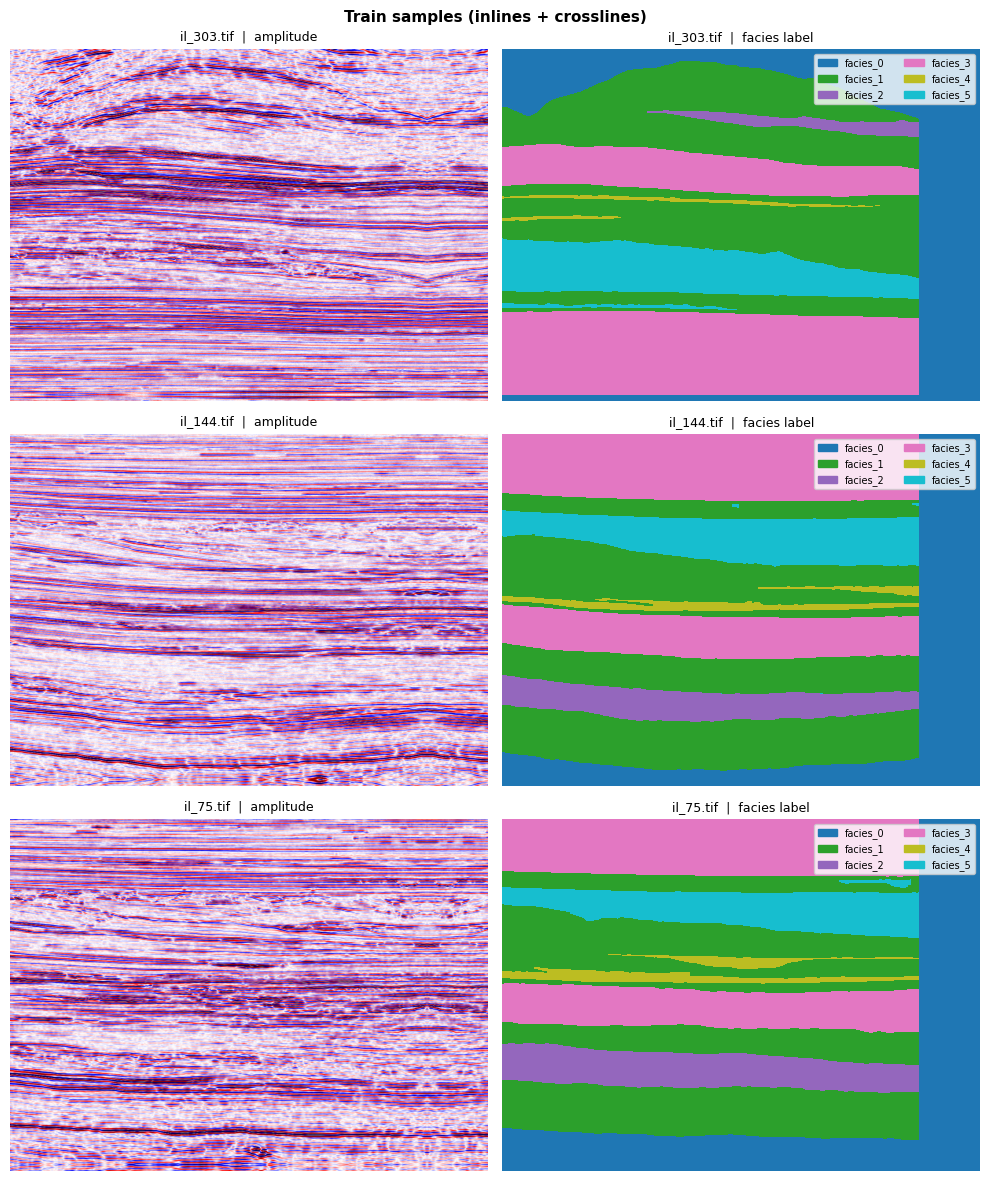

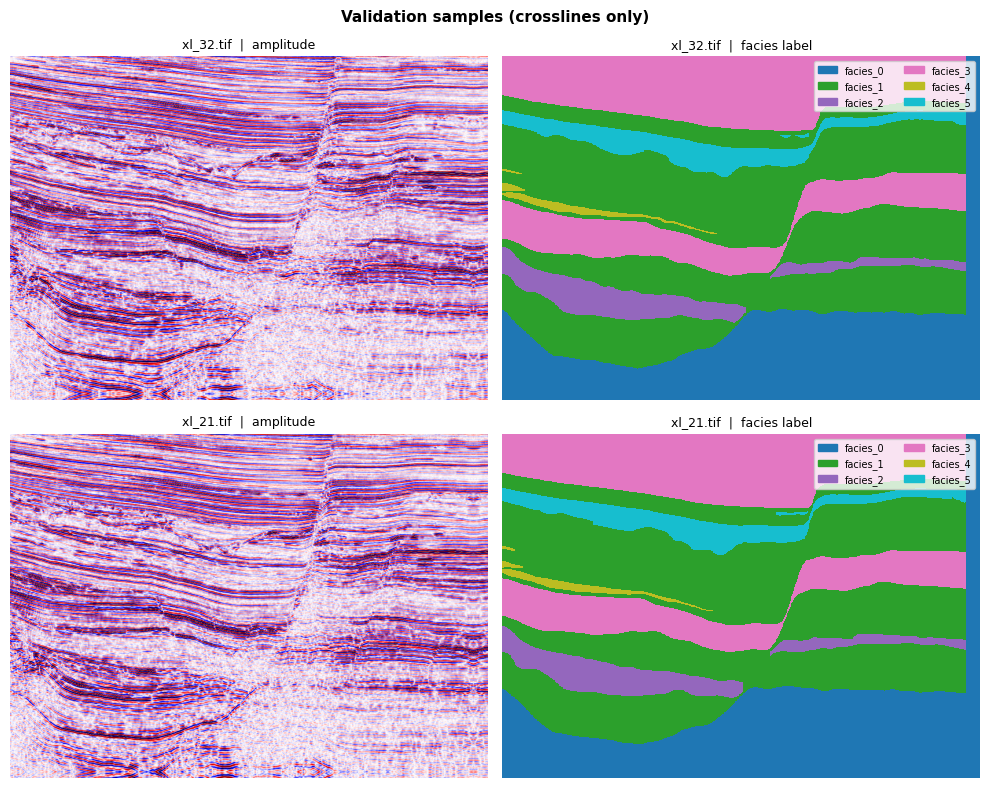

In [6]:
# Colour palette for facies labels
PALETTE = plt.cm.get_cmap("tab10", NUM_CLASSES)
FACIES_CMAP = ListedColormap([PALETTE(i) for i in range(NUM_CLASSES)])

def show_samples(dataset, n=3, title=""):
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 2, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]
    for ax_row, idx in zip(axes, idxs):
        amp_t, lbl_t, fname = dataset[idx]
        amp_np = amp_t[0].numpy()          # (H, W)
        lbl_np = lbl_t.numpy()             # (H, W)

        ax_row[0].imshow(amp_np, cmap="seismic", aspect="auto",
                         vmin=-3, vmax=3)
        ax_row[0].set_title(f"{fname}  |  amplitude", fontsize=9)
        ax_row[0].axis("off")

        im = ax_row[1].imshow(lbl_np, cmap=FACIES_CMAP,
                              vmin=0, vmax=NUM_CLASSES - 1,
                              aspect="auto", interpolation="nearest")
        ax_row[1].set_title(f"{fname}  |  facies label", fontsize=9)
        ax_row[1].axis("off")
        patches = [mpatches.Patch(color=PALETTE(i), label=CLASS_NAMES[i])
                   for i in range(NUM_CLASSES)]
        ax_row[1].legend(handles=patches, loc="upper right",
                         fontsize=7, ncol=2)
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_samples(train_ds, n=3, title="Train samples (inlines + crosslines)")
show_samples(val_ds,   n=2, title="Validation samples (crosslines only)")

## 4 — Class Distribution (important for imbalance handling)

Computing class distribution over train set (may take a moment)...


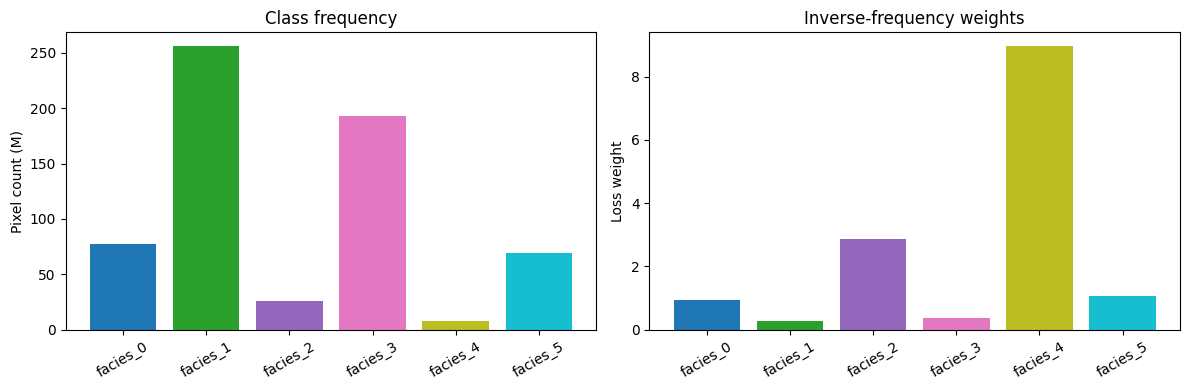

  facies_0              77,819,462 px   weight=0.947
  facies_1              255,772,476 px   weight=0.288
  facies_2              25,647,320 px   weight=2.873
  facies_3              193,311,692 px   weight=0.381
  facies_4               8,227,138 px   weight=8.957
  facies_5              69,561,392 px   weight=1.059


In [7]:
def compute_class_weights(dataset, num_classes):
    """
    Count pixels per class over the full dataset, return inverse-frequency
    weights suitable for CrossEntropyLoss.
    """
    counts = np.zeros(num_classes, dtype=np.int64)
    for _, lbl_t, _ in dataset:
        lbl = lbl_t.numpy().ravel()
        for c in range(num_classes):
            counts[c] += (lbl == c).sum()

    total = counts.sum()
    freq  = counts / total
    # Inverse median-frequency weighting (Eigen & Fergus 2015)
    median_freq = np.median(freq[freq > 0])
    weights = np.where(freq > 0, median_freq / freq, 0.0).astype(np.float32)
    return counts, weights

print("Computing class distribution over train set (may take a moment)...")
class_counts, class_weights = compute_class_weights(train_ds, NUM_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(CLASS_NAMES, class_counts / 1e6, color=[PALETTE(i) for i in range(NUM_CLASSES)])
axes[0].set_ylabel("Pixel count (M)"); axes[0].set_title("Class frequency")
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(CLASS_NAMES, class_weights, color=[PALETTE(i) for i in range(NUM_CLASSES)])
axes[1].set_ylabel("Loss weight"); axes[1].set_title("Inverse-frequency weights")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

for i, (c, w) in enumerate(zip(class_counts, class_weights)):
    print(f"  {CLASS_NAMES[i]:20s}  {c:>10,} px   weight={w:.3f}")

## 5 — Model, Loss, Optimiser

In [8]:
# ── Build model ────────────────────────────────────────────────────────────
_factories = {
    "tiny":  mamba_seg_tiny,
    "small": mamba_seg_small,
    "base":  mamba_seg_base,
    "large": mamba_seg_large,
}
model = _factories[MODEL_VARIANT](num_classes=NUM_CLASSES, in_channels=IN_CHANNELS)
print(f"Model variant  : mamba_seg_{MODEL_VARIANT}")
print(f"Parameters     : {model.count_parameters() / 1e6:.1f} M")

# ── Load pretrained encoder (optional) ────────────────────────────────────
if PRETRAINED and IN_CHANNELS == 3:
    # VMamba was pretrained on 3-channel ImageNet; only works with in_channels=3
    load_vmamba_pretrained(model, variant=MODEL_VARIANT)
elif PRETRAINED and IN_CHANNELS != 3:
    print("[INFO] PRETRAINED=True skipped: VMamba weights require IN_CHANNELS=3.")
    print("       Set IN_CHANNELS=3 above to use pretrained weights.")

model = model.to(DEVICE)

# ── Loss ───────────────────────────────────────────────────────────────────
cw_tensor = torch.tensor(class_weights, device=DEVICE)
criterion = DiceCELoss(ce_weight=1.0, dice_weight=1.0, class_weights=cw_tensor, ignore_index=-1)

# ── Optimiser — layer-wise LR (encoder slower than decoder) ───────────────
if PRETRAINED and IN_CHANNELS == 3:
    param_groups = get_param_groups_layerwise_lr(
        model, base_lr=BASE_LR, encoder_lr_scale=ENCODER_LR_SCALE, weight_decay=WEIGHT_DECAY
    )
else:
    param_groups = model.get_param_groups(weight_decay=WEIGHT_DECAY)

optimizer = torch.optim.AdamW(param_groups, lr=BASE_LR)

# ── LR scheduler: cosine annealing with warm-up ────────────────────────────
warmup_epochs = 5
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    t = (epoch - warmup_epochs) / max(EPOCHS - warmup_epochs, 1)
    return 0.5 * (1.0 + np.cos(np.pi * t))   # cosine decay to 0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Freeze encoder for first FREEZE_EPOCHS (pretrained case) ──────────────
if PRETRAINED and IN_CHANNELS == 3 and FREEZE_EPOCHS > 0:
    freeze_encoder(model)
    print(f"[Train] Encoder frozen for first {FREEZE_EPOCHS} epoch(s).")

Model variant  : mamba_seg_tiny
Parameters     : 6.1 M
[INFO] PRETRAINED=True skipped: VMamba weights require IN_CHANNELS=3.
       Set IN_CHANNELS=3 above to use pretrained weights.


## 6 — Training & Validation Utilities

In [9]:
def compute_metrics(logits, targets, num_classes):
    """
    Compute per-class IoU and mean IoU from a batch of logits and targets.
    Returns (miou, per_class_iou).
    """
    preds = logits.argmax(dim=1)   # (B, H, W)
    iou_per_class = []
    for c in range(num_classes):
        pred_c   = (preds   == c)
        target_c = (targets == c)
        inter    = (pred_c & target_c).sum().item()
        union    = (pred_c | target_c).sum().item()
        iou_per_class.append(inter / (union + 1e-8) if union > 0 else float("nan"))
    valid = [v for v in iou_per_class if not np.isnan(v)]
    miou  = np.mean(valid) if valid else 0.0
    return miou, iou_per_class


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss, total_miou, n = 0.0, 0.0, 0
    for amp, lbl, _ in loader:
        amp, lbl = amp.to(device), lbl.to(device)
        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:                     # mixed precision
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                logits = model(amp)
                loss   = criterion(logits, lbl)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(amp)
            loss   = criterion(logits, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        with torch.no_grad():
            miou, _ = compute_metrics(logits.detach(), lbl, NUM_CLASSES)
        total_loss += loss.item()
        total_miou += miou
        n += 1
    return total_loss / n, total_miou / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    # Accumulate confusion for global IoU
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    for amp, lbl, _ in loader:
        amp, lbl = amp.to(device), lbl.to(device)
        logits   = model(amp)
        loss     = criterion(logits, lbl)
        total_loss += loss.item(); n += 1
        preds = logits.argmax(1).cpu().numpy().ravel()
        lbls  = lbl.cpu().numpy().ravel()
        for p, t in zip(preds, lbls):
            if 0 <= t < NUM_CLASSES:
                conf[t, p] += 1

    # Per-class IoU from confusion matrix
    iou_per_class = []
    for c in range(NUM_CLASSES):
        tp    = conf[c, c]
        fn    = conf[c, :].sum() - tp
        fp    = conf[:, c].sum() - tp
        denom = tp + fp + fn
        iou_per_class.append(tp / denom if denom > 0 else float("nan"))
    valid = [v for v in iou_per_class if not np.isnan(v)]
    miou  = np.mean(valid) if valid else 0.0
    return total_loss / n, miou, iou_per_class

## 7 — Training Loop

In [10]:
# Mixed precision (skip if no CUDA)
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None

history = {"train_loss": [], "train_miou": [], "val_loss": [], "val_miou": []}
best_val_miou  = 0.0
best_ckpt_path = CHECKPOINT_DIR / f"best_mamba_seg_{MODEL_VARIANT}.pth"

for epoch in range(1, EPOCHS + 1):

    # ── Unfreeze encoder after FREEZE_EPOCHS ──
    if PRETRAINED and IN_CHANNELS == 3 and epoch == FREEZE_EPOCHS + 1:
        unfreeze_encoder(model)
        print(f"\n[Epoch {epoch}] Encoder unfrozen — fine-tuning everything.")

    train_loss, train_miou = train_one_epoch(model, train_dl, criterion, optimizer, DEVICE, scaler)
    val_loss,   val_miou, val_iou = evaluate(model, val_dl, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_miou"].append(train_miou)
    history["val_loss"].append(val_loss)
    history["val_miou"].append(val_miou)

    # ── Save best checkpoint ──
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({
            "epoch":      epoch,
            "model":      model.state_dict(),
            "optimizer":  optimizer.state_dict(),
            "val_miou":   val_miou,
            "class_names": CLASS_NAMES,
        }, best_ckpt_path)
        flag = "  ◀ best"
    else:
        flag = ""

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:3d}/{EPOCHS}  "
          f"loss {train_loss:.4f}/{val_loss:.4f}  "
          f"mIoU {train_miou:.4f}/{val_miou:.4f}  "
          f"lr {lr_now:.2e}"
          f"{flag}")

print(f"\nTraining complete. Best val mIoU: {best_val_miou:.4f}")

/tmp/ipykernel_29/2032897121.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if DEVICE.type == "cuda" else None


: 

: 

: 

## 8 — Learning Curves

In [ ]:
epochs_x = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_x, history["train_loss"], label="train")
axes[0].plot(epochs_x, history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("DiceCE Loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs_x, history["train_miou"], label="train")
axes[1].plot(epochs_x, history["val_miou"],   label="val")
axes[1].axvline(FREEZE_EPOCHS, color="gray", linestyle="--",
                label=f"encoder unfreezes (ep {FREEZE_EPOCHS})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mIoU")
axes[1].set_title("Mean IoU"); axes[1].legend()

plt.suptitle(f"mamba_seg_{MODEL_VARIANT}  |  {NUM_CLASSES} classes", fontweight="bold")
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "learning_curves.png", dpi=150)
plt.show()

## 9 — Test Set Evaluation

In [ ]:
# Load best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val mIoU={ckpt['val_miou']:.4f})")

test_loss, test_miou, test_iou = evaluate(model, test_dl, criterion, DEVICE)
print(f"\nTest loss : {test_loss:.4f}")
print(f"Test mIoU : {test_miou:.4f}\n")

# Per-class IoU table
print(f"{'Class':22s}  {'IoU':>7s}")
print("-" * 32)
for name, iou in zip(CLASS_NAMES, test_iou):
    val_str = f"{iou:.4f}" if not np.isnan(iou) else "  n/a "
    print(f"  {name:20s}  {val_str}")
print("-" * 32)
print(f"  {'mIoU':20s}  {test_miou:.4f}")

## 10 — Per-class IoU Bar Chart

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
clean_iou = [v if not np.isnan(v) else 0.0 for v in test_iou]
bars = ax.bar(CLASS_NAMES, clean_iou,
              color=[PALETTE(i) for i in range(NUM_CLASSES)])
ax.axhline(test_miou, color="black", linestyle="--",
           linewidth=1.5, label=f"mIoU = {test_miou:.3f}")
for bar, val in zip(bars, clean_iou):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("IoU")
ax.set_title(f"Test IoU per facies class  —  mamba_seg_{MODEL_VARIANT}")
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "test_iou.png", dpi=150)
plt.show()

## 11 — Visual Inference on Test Slices

In [ ]:
def visualise_predictions(model, dataset, device, n=4, save_path=None):
    """
    Side-by-side: amplitude  |  ground truth  |  prediction  |  difference
    """
    model.eval()
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4.5 * n))
    if n == 1:
        axes = [axes]
    col_titles = ["Amplitude", "Ground Truth", "Prediction", "Errors"]

    for row, idx in enumerate(idxs):
        amp_t, lbl_t, fname = dataset[idx]
        with torch.no_grad():
            logits = model(amp_t.unsqueeze(0).to(device))
        pred = logits.squeeze(0).argmax(0).cpu().numpy()
        gt   = lbl_t.numpy()
        amp  = amp_t[0].numpy()

        ax = axes[row]
        ax[0].imshow(amp,  cmap="seismic", aspect="auto", vmin=-3, vmax=3)
        ax[1].imshow(gt,   cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1, aspect="auto", interpolation="nearest")
        ax[2].imshow(pred, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1, aspect="auto", interpolation="nearest")

        # Error map (red = wrong, white = correct)
        err = (pred != gt).astype(np.float32)
        ax[3].imshow(err, cmap="Reds", aspect="auto", vmin=0, vmax=1)

        # Compute slice-level mIoU for the caption
        with torch.no_grad():
            slice_miou, _ = compute_metrics(
                logits.cpu(), lbl_t.unsqueeze(0), NUM_CLASSES
            )

        for a, title in zip(ax, col_titles):
            a.axis("off")
            a.set_title(title, fontsize=9)
        ax[0].set_ylabel(f"{fname}\nmIoU={slice_miou:.3f}", fontsize=8)

    patches = [mpatches.Patch(color=PALETTE(i), label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES,
               fontsize=8, bbox_to_anchor=(0.5, -0.01))
    plt.suptitle(f"mamba_seg_{MODEL_VARIANT} — Test set predictions",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

visualise_predictions(model, test_ds, DEVICE, n=4,
                      save_path=CHECKPOINT_DIR / "predictions.png")

## 12 — Full-section Inference (no patch size constraint)

For large seismic sections that don't fit in one `PATCH_SIZE × PATCH_SIZE` window,
this cell runs inference on the full native resolution using overlapping tiles.

In [ ]:
@torch.no_grad()
def predict_full_section(
    model,
    tiff_path: str,
    device,
    tile_size: int = 512,
    overlap: int = 64,
    in_channels: int = 1,
) -> np.ndarray:
    """
    Run inference on a full seismic section (any resolution) using overlapping
    tiles with Gaussian blending to avoid tile-boundary artefacts.

    Returns a (H, W) integer array of predicted class labels.
    """
    amp = tifffile.imread(tiff_path).astype(np.float32)
    if amp.ndim == 3:
        amp = amp[0] if amp.shape[0] < amp.shape[-1] else amp[..., 0]
    H, W = amp.shape

    # Normalise
    amp = (amp - amp.mean()) / (amp.std() + 1e-8)

    # Pad to multiple of (tile_size - overlap)
    stride = tile_size - overlap
    pad_h  = (stride - H % stride) % stride
    pad_w  = (stride - W % stride) % stride
    amp_pad = np.pad(amp, ((0, pad_h), (0, pad_w)), mode="reflect")
    Hp, Wp  = amp_pad.shape

    # Gaussian weight window for smooth blending
    import scipy.ndimage as ndi
    win_1d = np.hanning(tile_size).astype(np.float32) + 1e-6
    win_2d = np.outer(win_1d, win_1d)

    logit_sum = np.zeros((NUM_CLASSES, Hp, Wp), dtype=np.float32)
    weight_sum = np.zeros((Hp, Wp), dtype=np.float32)

    model.eval()
    for y in range(0, Hp - tile_size + 1, stride):
        for x in range(0, Wp - tile_size + 1, stride):
            tile = amp_pad[y:y+tile_size, x:x+tile_size]
            t    = torch.from_numpy(tile).unsqueeze(0).unsqueeze(0)  # (1,1,T,T)
            if in_channels == 3:
                t = t.repeat(1, 3, 1, 1)
            t = t.to(device)
            logits = model(t).squeeze(0).cpu().numpy()   # (C, T, T)
            logit_sum[:, y:y+tile_size, x:x+tile_size] += logits * win_2d
            weight_sum[y:y+tile_size, x:x+tile_size]   += win_2d

    # Normalise and remove padding
    logit_sum /= (weight_sum[None] + 1e-8)
    pred = logit_sum.argmax(0)[:H, :W]   # (H, W)
    return pred.astype(np.int32)


# ── Demo: run on the first test file ──────────────────────────────────────
if len(test_ds.samples) > 0:
    demo_tiff, demo_lbl_path = test_ds.samples[0]
    pred_full = predict_full_section(
        model, str(demo_tiff), DEVICE,
        tile_size=min(CANVAS_H, CANVAS_W), overlap=64, in_channels=IN_CHANNELS
    )
    gt_full = np.array(Image.open(demo_lbl_path), dtype=np.int32)
    if gt_full.ndim == 3:
        gt_full = gt_full[..., 0]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    amp_full = tifffile.imread(str(demo_tiff)).astype(np.float32)
    if amp_full.ndim == 3:
        amp_full = amp_full[0]

    axes[0].imshow(amp_full, cmap="seismic", aspect="auto",
                   vmin=np.percentile(amp_full, 2), vmax=np.percentile(amp_full, 98))
    axes[0].set_title(f"{demo_tiff.name} — Amplitude"); axes[0].axis("off")

    axes[1].imshow(gt_full[:pred_full.shape[0], :pred_full.shape[1]],
                   cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                   aspect="auto", interpolation="nearest")
    axes[1].set_title("Ground Truth"); axes[1].axis("off")

    axes[2].imshow(pred_full, cmap=FACIES_CMAP, vmin=0, vmax=NUM_CLASSES-1,
                   aspect="auto", interpolation="nearest")
    axes[2].set_title("Prediction (full section, tiled)"); axes[2].axis("off")

    patches = [mpatches.Patch(color=PALETTE(i), label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=NUM_CLASSES,
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig(CHECKPOINT_DIR / "full_section_prediction.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13 — Save Final Checkpoint

In [ ]:
final_path = CHECKPOINT_DIR / f"final_mamba_seg_{MODEL_VARIANT}.pth"
torch.save({
    "model":        model.state_dict(),
    "num_classes":  NUM_CLASSES,
    "in_channels":  IN_CHANNELS,
    "variant":      MODEL_VARIANT,
    "canvas_h":     CANVAS_H,
    "canvas_w":     CANVAS_W,
    "class_names":  CLASS_NAMES,
    "test_miou":    test_miou,
    "test_iou":     test_iou,
    "history":      history,
}, final_path)
print(f"Final checkpoint saved: {final_path}")
print(f"Test mIoU: {test_miou:.4f}")